# Module 4 Lab 1: Describing Data

**Name:** Mac Mckay

**Course:** CS 82A

**Repo:** https://github.com/raulmckay-blip/cs82a-portfolio

## Overview

This lab uses the sales data I cleaned in Module 3 (`sales_clean.csv`) to practice describing data: center, spread, shape, and how two columns move together.

## Step 1: Load the clean data

My file comes out as (292, 7) instead of (292, 6) because I kept the `is_return` column from the Module 3 cleaning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sales_clean.csv')
print(df.shape)   # (292, 7)
df.head()

(292, 7)


,order_id,date,product,price,qty,zip,is_return
0,1254,2026-04-06,mug,11.36,4,60614,False
1,1057,2026-05-30,charger,14.79,3,30303,False
2,1150,2026-05-06,mug,5.50,1,10001,False
3,1066,2026-05-30,notebook,37.53,1,98101,False
4,1114,2026-04-06,webcam,45.59,4,90405,False


## Step 2: Center and spread of `price` and `qty`

In [ ]:
for col in ['price', 'qty']:
    print(f"{col:>5}  mean={df[col].mean():.2f}  median={df[col].median():.2f}  std={df[col].std():.2f}")

price  mean=55.52  median=37.53  std=71.77
  qty  mean=2.91  median=3.00  std=1.56


## Step 3: Which summary would I report for price?

I would report the median. The mean is $55.52 but the median is only $37.53, so a few expensive items are pulling the mean up. The median gives a better idea of what a normal item actually costs.

## Step 4: Histogram of price

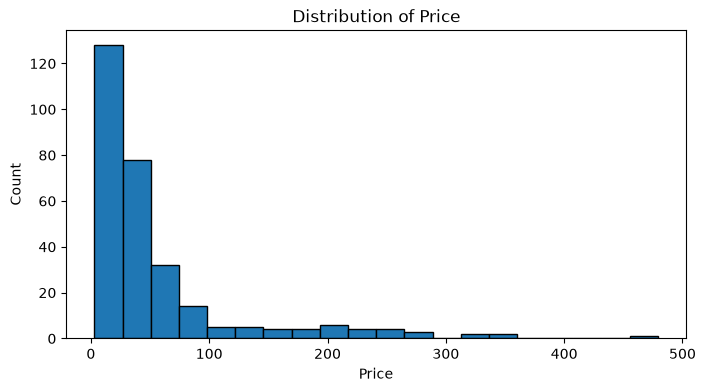

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=20, edgecolor='black')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

The histogram is right skewed. Most prices are bunched up on the low end and there's a long tail of expensive items to the right.

This matches what I said in Step 3. Skew pulls the mean toward the tail, which is why the median is the better choice here.

## Step 5: Create the `revenue` column

In [ ]:
df['revenue'] = df['price'] * df['qty']
print(df.shape)   # should be 8 columns now
df.head()

(292, 8)


,order_id,date,product,price,qty,zip,is_return,revenue
0,1254,2026-04-06,mug,11.36,4,60614,False,45.44
1,1057,2026-05-30,charger,14.79,3,30303,False,44.37
2,1150,2026-05-06,mug,5.50,1,10001,False,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,False,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,False,182.36


## Step 6: Correlation matrix

I left out `order_id` and `zip`. They're stored as numbers but they're really just labels, so a correlation on them wouldn't mean anything.

In [ ]:
corr = df[['price', 'qty', 'revenue']].corr()
corr.round(2)

,price,qty,revenue
price,1.00,-0.02,0.82
qty,-0.02,1.00,0.33
revenue,0.82,0.33,1.00


In [ ]:
# find the strongest pair (skipping the 1s on the diagonal)
pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
top = pairs.index[0]
print(f"Strongest pair: {top[0]} vs {top[1]}  r = {corr.loc[top]:.2f}")

Strongest pair: price vs revenue  r = 0.82


The strongest pair is `price` vs `revenue` at r = 0.82. The lab said `qty` vs `revenue` should be the standout, but in my data it's only 0.33. I think it's because price varies way more than qty (std of 71.77 vs 1.56), so price ends up driving most of the difference in revenue.

## Step 7: Scatter plot to verify

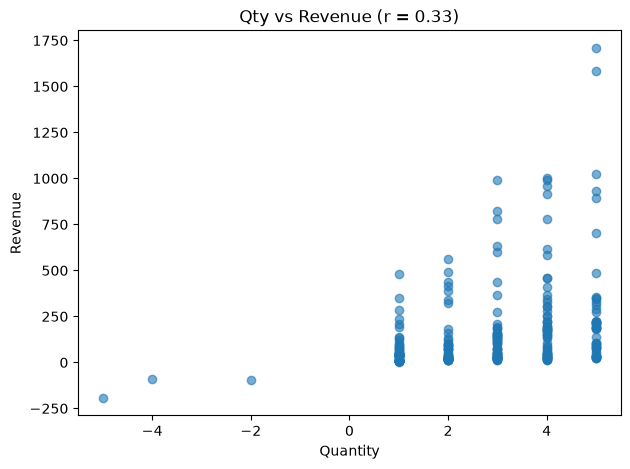

In [ ]:
r = df['qty'].corr(df['revenue'])
plt.figure(figsize=(7, 5))
plt.scatter(df['qty'], df['revenue'], alpha=0.6)
plt.title(f'Qty vs Revenue (r = {r:.2f})')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

The points drift upward but it's loose. There's a lot of spread at each qty level, which makes sense for an r of 0.33.

## Step 8: The analyst's sentence

Orders with more units tend to bring in more revenue, but it's only a moderate relationship (r = 0.33), not a tight one. One thing to be careful about is that price is really skewed, so a few expensive items can swing revenue a lot more than qty does.

## Step 9: By-hand check

Data: `[2, 4, 4, 6, 9]`

**Mean:** 2 + 4 + 4 + 6 + 9 = 25, and 25 / 5 = **5.0**

**Median:** The list is already sorted and has 5 numbers, so the median is the 3rd one, which is **4**.

In [ ]:
vals = [2, 4, 4, 6, 9]
print('mean  :', np.mean(vals))
print('median:', np.median(vals))

mean  : 5.0
median: 4.0


## AI Use

I used AI to help with syntax and refine wording on this lab.